# Multi-Agent-System-with-Human-in-the-Loop-Feedback-for-CMOS-Optimization
I developed a "Human-in-the-Loop" (HITL) multi-agent system using the Google Agent Development Kit (ADK) to automate the complex process of transistor sizing in circuit design.

**The Problem**

Manually sizing transistors to meet specific performance targets (like speed and voltage symmetry) is a tedious, iterative process.

**The Solution**

I built a specialized AI workforce where each agent handles a specific part of the design cycle:

* Theoretical Analysis: A "CircuitExplainer" agent determines how transistor widths will impact performance.

* Automated Simulation: Agents autonomously write and run ngspice scripts to test the circuit after each iteration of parameter modification.

* Intelligent Optimization: A "Sizer" agent analyzes simulation data and proposes adjustments.

* Human-in-the-Loop: To speed up convergence to a solution, the system pauses to request expert feedback (e.g., "Double the size") before proceeding, combining AI speed with human oversight.

**The Result**

The agentic workflow successfully optimized a CMOS inverter from a failing state (900ps delay) to meeting all strict design specifications (< 50ps delay) within just a few automated iterations.

In [ ]:
from IPython.display import HTML, display

def set_css():
  display(HTML('''
  <style>
    pre {
      white-space: pre-wrap;
    }
  </style>
  '''))

get_ipython().events.register('pre_run_cell', set_css)


In [ ]:
!apt-get install ngspice
!ngspice -v
!pip install google-adk

In [ ]:
# Google ADK Imports
from google.adk.agents import LlmAgent, SequentialAgent, LoopAgent, ParallelAgent
from google.adk.tools import AgentTool, FunctionTool
from google.adk.tools.exit_loop_tool import exit_loop
from google.adk.models.google_llm import Gemini
from google.adk.sessions import InMemorySessionService
from google.adk.runners import Runner, InMemoryRunner
from google.genai import types
from google.adk.tools.tool_context import ToolContext
from google.colab import userdata
import asyncio

# Get your API key from Colab secrets
raw_key = userdata.get('Joon_Choi_API_KEY')

# FIX: Clean the key to remove newlines or whitespace that cause header injection errors
if raw_key:
    GOOGLE_API_KEY = raw_key.strip().split('\n')[0].strip()
else:
    GOOGLE_API_KEY = "MISSING_KEY"

# You can then set it as an environment variable or pass it directly to your configuration
import os
os.environ['GOOGLE_API_KEY'] = GOOGLE_API_KEY

print("API key loaded and cleaned.")

retry_config=types.HttpRetryOptions(
    attempts=5,  # Maximum retry attempts
    exp_base=7,  # Delay multiplier
    initial_delay=1,
    http_status_codes=[429, 500, 503, 504], # Retry on these HTTP errors
)

API key loaded and cleaned.


# Simulations
**1. DC (Direct Current) Design**

The "Sizer" agent uses DC Sweep analysis to evaluate the Voltage Transfer Characteristic (VTC).
* The Goal: To ensure the circuit is "balanced" or symmetrical.
* The Parameter: It looks for specific voltage thresholds (like $v_{hl10}$ and $v_{lh90}$) to ensure the inverter switches states precisely around the $0.6V$ mark (half of the $1.2V$ supply).

**2. AC / Transient Design**

The "TransReviewer" agent performs Transient Analysis, which measures how the circuit behaves over a period of time when the input signal changes rapidly.
* The Goal: To ensure the circuit is fast enough for high-speed applications.
* The Parameter: It calculates rise and fall times ($t_{lh}$ and $t_{hl}$). In your code, the agents iteratively increased the transistor widths specifically because the initial "AC" performance was too slow (900ps) and needed to be brought down to under 50ps.

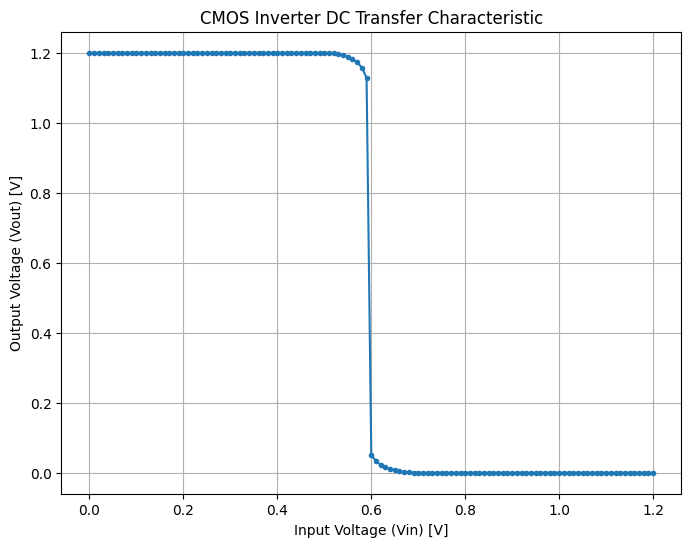

'{"v_hl10": 0.5994, "v_hl90": 0.5904, "v_lh10": 0.5994, "v_lh90": 0.5905}'


In [ ]:
import subprocess
import numpy as np
import json
from pprint import pprint
import matplotlib.pyplot as plt
def simulate_cmos_inverter(wp: str, wn: str) -> str:
    """
    Runs a forward and backward DC sweep for a CMOS Inverter to extract critical Voltage Transfer Characteristic (VTC) points.

    Args:
        wp (str): PMOS width with unit (e.g., '2u', '40n').
        wn (str): NMOS width with unit (e.g., '1u', '40n').

    Returns:
        str: A JSON string containing Vin (Input Voltage) values at specific Vout (Output Voltage) thresholds:
            - v_hl10: Vin where Vout=0.12V (10% of VDD) during High-to-Low output transition. (H->L End of transition)
            - v_hl90: Vin where Vout=1.08V (90% of VDD) during High-to-Low output transition. (H->L Start of transition)
            - v_lh10: Vin where Vout=0.12V (10% of VDD) during Low-to-High output transition. (L->H Start of transition)
            - v_lh90: Vin where Vout=1.08V (90% of VDD) during Low-to-High output transition. (L->H End of transition)
    """
    lp="40n"
    ln="40n"
    def run_sweep(start_v, stop_v, step_v, filename_suffix):
# .model model0_nmos nmos level=1 vto=0.35 kp=400u lambda=0.05
# .model model0_pmos pmos level=1 vto=-0.35 kp=200u lambda=0.05
        # Define Netlist
        netlist = f"""* CMOS Inverter
.model model0_nmos nmos(level=1 vto=0.5 kp=35.2e-6 gamma=0.91 + cgso=210pF cgdo=210pF tox=50n)
.model model0_pmos pmos(level=1 vto=-0.5 kp=13.4e-6 gamma=0.64 + cgso=210pF cgdo=210pF tox=50n)

VDD vdd 0 1.2
VIN in 0 0
M1 out in vdd vdd model0_pmos w={wp} l={lp}
M2 out in 0 0 model0_nmos w={wn} l={ln}
C1 out 0 5f
.dc VIN {start_v} {stop_v} {step_v}
.print dc v(out)
.end
"""
        filename = f"inverter_{filename_suffix}.cir"
        with open(filename, 'w') as f:
            f.write(netlist)

        try:
            result = subprocess.run(['ngspice', '-b', filename], capture_output=True, text=True, check=True)
            output = result.stdout
        except subprocess.CalledProcessError as e:
            print(f"Error running ngspice ({filename_suffix}):", e.stderr)
            return [], []

        vin_list = []
        vout_list = []
        lines = output.split('\n')
        start_parsing = False
        for line in lines:
            if not line.strip(): continue
            if '-----' in line:
                start_parsing = True
                continue
            if start_parsing:
                parts = line.split()
                if len(parts) >= 3:
                    try:
                        vin_list.append(float(parts[1]))
                        vout_list.append(float(parts[2]))
                    except ValueError:
                        continue
        return np.array(vin_list), np.array(vout_list)

    vin_f, vout_f = run_sweep("0", "1.2", "0.01", "fwd")
    vin_b, vout_b = run_sweep("1.2", "0", "-0.01", "bwd")
    plt.figure(figsize=(8, 6))
    plt.plot(vin_f, vout_f, marker='.', linestyle='-')
    plt.title('CMOS Inverter DC Transfer Characteristic')
    plt.xlabel('Input Voltage (Vin) [V]')
    plt.ylabel('Output Voltage (Vout) [V]')
    plt.grid(True)
    plt.show()
    # Interp for Vout=0.12 (10%) and 1.08 (90%)
    res = {
        "v_hl10": round(float(np.interp(0.12, vout_f[::-1], vin_f[::-1])), 4),
        "v_hl90": round(float(np.interp(1.08, vout_f[::-1], vin_f[::-1])), 4),
        "v_lh10": round(float(np.interp(0.12, vout_b, vin_b)), 4),
        "v_lh90": round(float(np.interp(1.08, vout_b, vin_b)), 4)
    }
    return json.dumps(res)

# Call the function
results = simulate_cmos_inverter("1850n", "925n")
pprint(results)

dc_sim = FunctionTool(simulate_cmos_inverter)

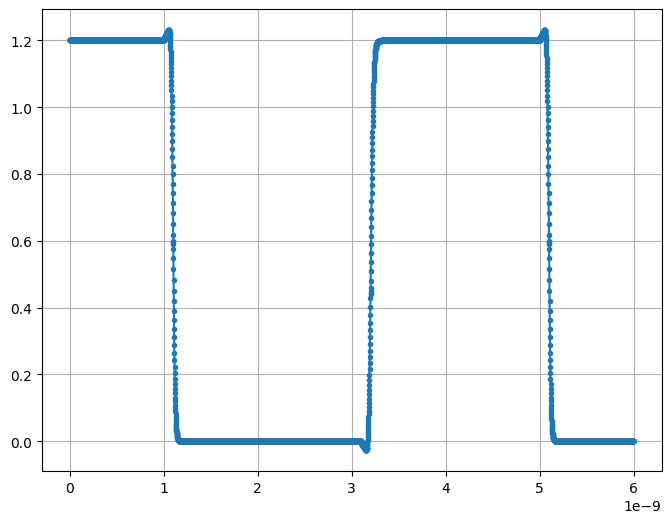

Transient Simulation Results:
{"t_hl": 40.974, "t_lh": 49.841}


In [ ]:
import subprocess
import numpy as np

def transient_sim(wp: str, wn: str) -> str:
    """
    Runs a transient simulation to measure propagation and transition delays.

    Args:
        wp (str): PMOS width with unit (e.g., '2u').
        wn (str): NMOS width with unit (e.g., '1u').

    Returns:
        str: A JSON string containing timing metrics in picoseconds (ps):
            - t_hl: Fall time in femtoseconds (High-to-Low) measured from 90% to 10% of VDD at the output.
            - t_lh: Rise time in femtoseconds (Low-to-High) measured from 10% to 90% of VDD at the output.
    """
    lp="40n"
    ln="40n"
    t_step="0.001ns"
    t_stop="6ns"
    # 1. Define the Netlist
    # PULSE(V1 V2 TD TR TF PW PER)
    # 0 to 1.2V, 5ns delay, 0.1ns rise, 0.1ns fall, 5ns width, 10ns period (100MHz)
    # Added C1 50fF capacitor at the output
    netlist = f"""* CMOS Inverter Transient Analysis
.model model0_nmos nmos(level=1 vto=0.5 kp=35.2e-6 gamma=0.91 + cgso=210pF cgdo=210pF tox=50n)
.model model0_pmos pmos(level=1 vto=-0.5 kp=13.4e-6 gamma=0.64 + cgso=210pF cgdo=210pF tox=50n)

VDD vdd 0 1.2
VIN in 0 PULSE(0 1.2 1ns 100ps 100ps 2ns 4ns)
M1 out in vdd vdd model0_pmos w={wp} l={lp}
M2 out in 0 0 model0_nmos w={wn} l={ln}
C1 out 0 5f
.tran {t_step} {t_stop}
.print tran v(in) v(out)
.end
"""
    filename = "transient.cir"

    # 2. Write the .cir file
    with open(filename, 'w') as f:
        f.write(netlist)

    # 3. Run Ngspice
    try:
        result = subprocess.run(['ngspice', '-b', filename], capture_output=True, text=True, check=True)
        output = result.stdout
    except subprocess.CalledProcessError as e:
        print("Error running ngspice:", e.stderr)
        return 0.0, 0.0

    # 4. Parse Results
    time_vals = []
    vout_vals = []
    lines = output.split('\n')
    start_parsing = False

    for line in lines:
        if not line.strip(): continue
        if '-----' in line:
            start_parsing = True
            continue
        if start_parsing:
            parts = line.split()
            if len(parts) >= 4:
                try:
                    time_vals.append(float(parts[1]))
                    vout_vals.append(float(parts[3]))
                except ValueError:
                    continue

    # 5. Calculate Transition Times
    time_arr = np.array(time_vals)
    vout_arr = np.array(vout_vals)
    plt.figure(figsize=(8, 6))
    plt.plot(time_arr, vout_arr, marker='.', linestyle='-')
    plt.grid(True)
    plt.show()
    # Thresholds (10% and 90% of 1.2V)
    v_high = 1.08
    v_low = 0.12

    # --- High-to-Low (Fall Time) ---
    # Find where Vout first drops below v_high
    # We look for the first falling edge. Vout starts at 1.2V.
    t_hl = 0.0
    # Indices where Vout < v_high
    below_high_indices = np.where(vout_arr < v_high)[0]
    if len(below_high_indices) > 0:
        idx_start = below_high_indices[0]
        # Interpolate start time
        if idx_start > 0:
            t_90 = np.interp(v_high, vout_arr[idx_start-1:idx_start+1][::-1], time_arr[idx_start-1:idx_start+1][::-1])

            # Find where it subsequently drops below v_low
            below_low_indices = np.where(vout_arr[idx_start:] < v_low)[0]
            if len(below_low_indices) > 0:
                idx_end = idx_start + below_low_indices[0]
                t_10 = np.interp(v_low, vout_arr[idx_end-1:idx_end+1][::-1], time_arr[idx_end-1:idx_end+1][::-1])
                t_hl = t_10 - t_90

    # --- Low-to-High (Rise Time) ---
    # Start search after the falling edge finished (approx after 10ns when input goes low)
    # Input period 10ns. Fall happens ~5ns. Rise happens ~10ns.
    # We look for crossing v_low upwards then v_high upwards.
    t_lh = 0.0
    start_search_idx = len(time_arr) // 3 # Skip the first part (falling edge)

    # Find where Vout rises above v_low
    above_low_indices = np.where(vout_arr[start_search_idx:] > v_low)[0]
    if len(above_low_indices) > 0:
        idx_start = start_search_idx + above_low_indices[0]
        if idx_start > 0:
            t_10_rise = np.interp(v_low, vout_arr[idx_start-1:idx_start+1], time_arr[idx_start-1:idx_start+1])

            # Find where it subsequently rises above v_high
            above_high_indices = np.where(vout_arr[idx_start:] > v_high)[0]
            if len(above_high_indices) > 0:
                idx_end = idx_start + above_high_indices[0]
                t_90_rise = np.interp(v_high, vout_arr[idx_end-1:idx_end+1], time_arr[idx_end-1:idx_end+1])
                t_lh = t_90_rise - t_10_rise

    return json.dumps({"t_hl": round(t_hl*1e12, 3), "t_lh": round(t_lh*1e12, 3)})

# Call the function
results = transient_sim("1850n", "925n")

# Verify
print("Transient Simulation Results:")
print(results)

trans_sim = FunctionTool(transient_sim)

In [ ]:
def update_width(Wp: str, Wn: str) -> dict:
  """
  Updates the transistor widths for the next optimization iteration.

  Use this tool ONLY when the specifications are not yet met and you need to
  propose new width values.

  Args:
      Wp (str): The new width for the PMOS transistor (e.g., '500n', '1u').
      Wn (str): The new width for the NMOS transistor (e.g., '200n', '0.5u').

  Returns:
      dict: A dictionary containing the new 'Wp' and 'Wn' keys and values,
            which will overwrite the 'current_params' in the loop.
  """
  return {"Wp": Wp, "Wn": Wn}
update_widths = FunctionTool(update_width)

"""Function doesn't need to be async in this case since the transistor resizing task must finish before the main thread (agentic workflow) continues to the next agent.
Thus, there is no other thread to run in parallel while waiting for the human feedback via this function (meaning blocking main thread with a synchronous function makes no difference).
However, in a real-world scenario where external_approval_tool would be interacting with an external system (e.g., an API call that awaits a response from a human review service),
then async and await would be essential. This allows the function to perform non-blocking I/O, enabling other parts of your asynchronous application (like other agents in the ADK workflow)
to continue running while waiting for the external approval.
Using async for tools that conceptually involve waiting for external events is good practice, which is why the function is async here.
"""
async def external_approval_tool(change: str) -> str:
  """
  Requests human approval or feedback for a proposed change.

  This tool is intended to simulate a human-in-the-loop process where an agent
  proposes a change (e.g., new transistor widths), and a human provides
  feedback or explicit approval/rejection. The human's response will guide
  the agent's subsequent actions.

  Args:
      change (str): A description of the proposed change that requires human
                    review (e.g., 'Proposed new Wp=1.2u, Wn=0.6u').

  Returns:
      str: The human's textual feedback regarding the proposed change. This
           could be 'approved', 'rejected', 'increase Wp more', 'try Wp=1u, Wn=0.5u',
           or any other guiding instruction.
  """
  user_input = await asyncio.to_thread(input, f"{change} \nDo you approve of this change: ")
  return user_input

approval_tool = FunctionTool(func=external_approval_tool)

#Agent workflow

In [ ]:
# --- Configuration ---
gemini_model = "gemini-2.5-flash-lite" # Use Pro for better numerical reasoning

# Step 1: Theoretical Analysis
explainer = LlmAgent(
    model=Gemini(model=gemini_model),
    name="CircuitExplainer",
    output_key="circuit_explanation",
    instruction="""
    You are an expert CMOS logic inverter circuit designer.
    Analyze the given target circuit specications.
    Explain concisely how Wp and Wn affects the VTC on a Vout vs Vin graph, as well as rising and falling times in transient simulations, so that the next agent can set informed initial widths.
    """
)

# Step 2: Informed Initialization (Avoids starting at 1u/1u)
initial_sizer = LlmAgent(
    model=Gemini(model=gemini_model),
    name="InitialSizer",
    output_key="current_params",
    instruction="""
    You are an expert in CMOS logic inverter circuit design.
    Based on the 'circuit_explanation' and pmos and nmos models, propose initial Wp and Wn values.
    Ensure the current through the pmos and nmos are at least 5uA.
    Format: JSON {"Wp": "...", "Wn": "..."}. Use 'u' or 'n' units."""
)

# Step 3: Optimization Loop
dc_reviewer = LlmAgent(
    model=Gemini(model=gemini_model),
    name="DCReviewer",
    output_key="dc_sim_result",
    tools=[dc_sim],
    instruction="""
    You are an expert in CMOS logic inverter circuit design.
    Execute dc_sim with current_params regardless of whether specs were previously met, and output the VTC intercept JSON.
    If the result is within the VTC spec range, say so. If not, tell how far the result is above or below the spec.
    """
)

trans_reviewer = LlmAgent(
    model=Gemini(model=gemini_model),
    name="TransReviewer",
    output_key="trans_sim_result",
    tools=[trans_sim],
    instruction="""
    You are an expert in CMOS logic inverter circuit design.
    Execute transient_sim with current_params regardless of whether specs were previously met, and output the timing JSON.
    If the result is within the transient spec range, say so. If not, tell how far the result is above or below the spec.
    """
)

sizer = LlmAgent(
    model=Gemini(model=gemini_model),
    name="Sizer",
    output_key="current_params",
    tools=[exit_loop, update_widths, approval_tool],
    instruction="""
    You are an expert in CMOS logic inverter circuit design.
    Evaluate 'dc_sim_result' and 'trans_sim_result' against the 'specs'.

    1. If ALL simulated values are within the [min, max] ranges for both VTC_Spec and Transient_Spec:
       Call the `exit_loop` tool.

    2. If ANY value is out of range:
       a. First, propose new 'Wp' and 'Wn' values based on your analysis of the 'dc_sim_result' and 'trans_sim_result' compared to the 'specs'.
          Remember that increasing Wp reduces t_lh and increasing Wn reduces t_hl. The ratio Wp/Wn should be around 2.6 for balanced VTC.
       b. Call the `approval_tool` with your proposed 'Wp' and 'Wn' values.
       c. Carefully consider the human's feedback, call the `update_widths` tool with the final, adjusted 'Wp' and 'Wn' values.
    Do NOT create a new function or try to run simulations.
    """
)

result_analyzer = LlmAgent(
    model=Gemini(model=gemini_model),
    name="ResultAnalyzer",
    output_key="final_result",
    tools=[dc_sim, trans_sim],
    instruction="""
    Run 'dc_sim' and 'trans_sim' using the final Wp and Wn values and present the final Wp and Wn values as well as the simulation results in a bulleted list.
    """
)

# Combine Sims and Sizer into a single loop step
loop_step = SequentialAgent(
    name="OptimizationStep",
    sub_agents=[ParallelAgent(name="Simulator", sub_agents=[dc_reviewer, trans_reviewer]), sizer]
)

phase2 = LoopAgent(name="SizingLoop", sub_agents=[loop_step], max_iterations=5)

# Final Assembly
workflow = SequentialAgent(
    name="CMOS_Design_Expert",
    sub_agents=[explainer, initial_sizer, phase2, result_analyzer]
)

✅ Session State Seeded with Placeholder Keys

--- Execution Start ---
✅ Generator created. Stepping through events...

[Event 1] 
model_version='gemini-2.5-flash-lite' content=Content(
  parts=[
    Part(
      text="""The width of the PMOS transistor ($W_p$) and the NMOS transistor ($W_n$) significantly influence the Voltage Transfer Characteristic (VTC) and transient response of a CMOS inverter.

**Impact on VTC:**

*   **Symmetry and Gain:** The ratio of $W_p$ to $W_n$ (often denoted as $\beta_p/\beta_n$ or $W_p/W_n$) is crucial for VTC symmetry. Ideally, for a VTC centered at $V_{DD}/2$, the ratio $W_p/W_n$ should be approximately equal to the ratio of their mobilities ($\mu_n / \mu_p$).
    *   **Increasing $W_p$ relative to $W_n$:** Shifts the VTC to the right, making the transition region occur at higher input voltages. The inverter will be weaker in sinking current (pulling down) and stronger in sourcing current (pulling up). This leads to a higher $V_{IL}$ and a lower $V_{IH}$


[Event 3] 
model_version='gemini-2.5-flash-lite' content=Content(
  parts=[
    Part(
      function_call=FunctionCall(
        args={
          'wn': '40n',
          'wp': '80n'
        },
        id='adk-c16f6aaa-b08a-4581-8a9e-8f92951da757',
        name='simulate_cmos_inverter'
      )
    ),
  ],
  role='model'
) grounding_metadata=None partial=None turn_complete=None finish_reason=<FinishReason.STOP: 'STOP'> error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=GenerateContentResponseUsageMetadata(
  candidates_token_count=28,
  prompt_token_count=2422,
  prompt_tokens_details=[
    ModalityTokenCount(
      modality=<MediaModality.TEXT: 'TEXT'>,
      token_count=2422
    ),
  ],
  total_token_count=2450
) live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id=None invocation_id='e-640442b6-4d13-47a5-8fb9-87b79211cfc

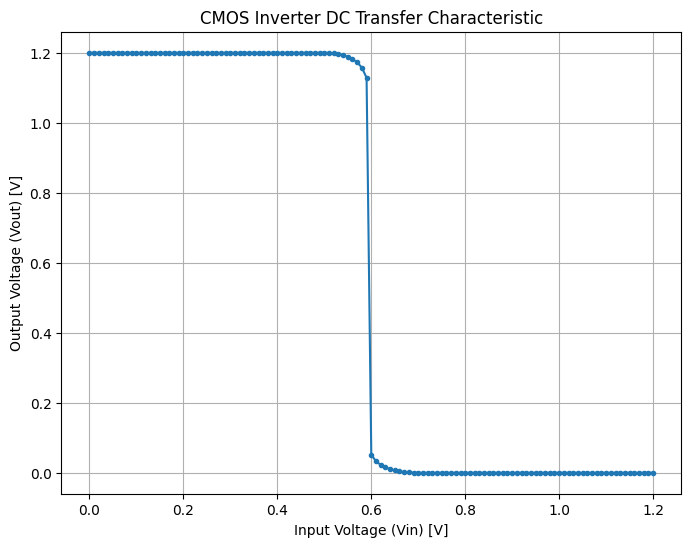


[Event 4] 
model_version=None content=Content(
  parts=[
    Part(
      function_response=FunctionResponse(
        id='adk-c16f6aaa-b08a-4581-8a9e-8f92951da757',
        name='simulate_cmos_inverter',
        response={
          'result': '{"v_hl10": 0.5994, "v_hl90": 0.5904, "v_lh10": 0.5994, "v_lh90": 0.5904}'
        }
      )
    ),
  ],
  role='user'
) grounding_metadata=None partial=None turn_complete=None finish_reason=None error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=None live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id=None invocation_id='e-640442b6-4d13-47a5-8fb9-87b79211cfc1' author='DCReviewer' actions=EventActions(skip_summarization=None, state_delta={}, artifact_delta={}, transfer_to_agent=None, escalate=None, requested_auth_configs={}, requested_tool_confirmations={}, compaction=None, end_of_

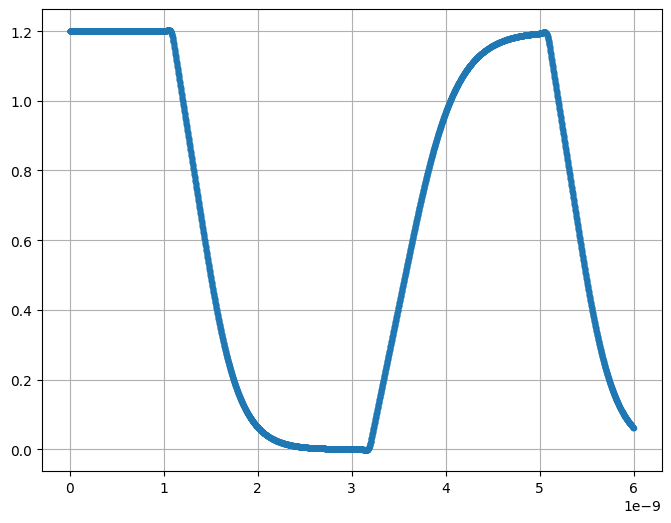


[Event 6] 
model_version=None content=Content(
  parts=[
    Part(
      function_response=FunctionResponse(
        id='adk-f35b8c90-5c77-4584-853e-3c709c5d0b08',
        name='transient_sim',
        response={
          'result': '{"t_hl": 704.225, "t_lh": 924.998}'
        }
      )
    ),
  ],
  role='user'
) grounding_metadata=None partial=None turn_complete=None finish_reason=None error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=None live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id=None invocation_id='e-640442b6-4d13-47a5-8fb9-87b79211cfc1' author='TransReviewer' actions=EventActions(skip_summarization=None, state_delta={}, artifact_delta={}, transfer_to_agent=None, escalate=None, requested_auth_configs={}, requested_tool_confirmations={}, compaction=None, end_of_agent=None, agent_state=None, rewind_before_

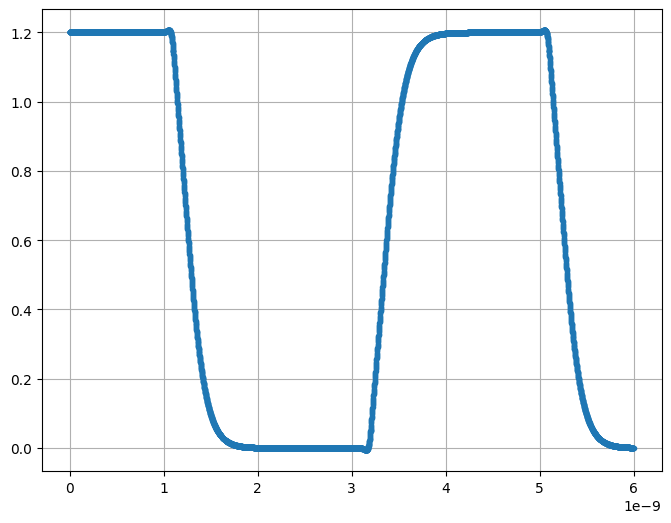


[Event 15] 
model_version=None content=Content(
  parts=[
    Part(
      function_response=FunctionResponse(
        id='adk-335a24d0-1cd6-437d-a832-adc65ab1bf8a',
        name='transient_sim',
        response={
          'result': '{"t_hl": 354.485, "t_lh": 372.53}'
        }
      )
    ),
  ],
  role='user'
) grounding_metadata=None partial=None turn_complete=None finish_reason=None error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=None live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id=None invocation_id='e-640442b6-4d13-47a5-8fb9-87b79211cfc1' author='TransReviewer' actions=EventActions(skip_summarization=None, state_delta={}, artifact_delta={}, transfer_to_agent=None, escalate=None, requested_auth_configs={}, requested_tool_confirmations={}, compaction=None, end_of_agent=None, agent_state=None, rewind_before_

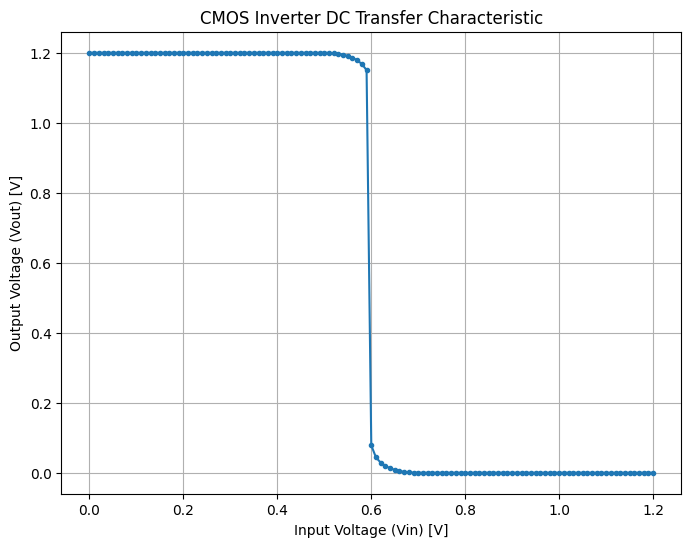


[Event 17] 
model_version=None content=Content(
  parts=[
    Part(
      function_response=FunctionResponse(
        id='adk-4b4f6941-ba69-4564-8d40-8d53dc314023',
        name='simulate_cmos_inverter',
        response={
          'result': '{"v_hl10": 0.5996, "v_hl90": 0.5907, "v_lh10": 0.5996, "v_lh90": 0.5907}'
        }
      )
    ),
  ],
  role='user'
) grounding_metadata=None partial=None turn_complete=None finish_reason=None error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=None live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id=None invocation_id='e-640442b6-4d13-47a5-8fb9-87b79211cfc1' author='DCReviewer' actions=EventActions(skip_summarization=None, state_delta={}, artifact_delta={}, transfer_to_agent=None, escalate=None, requested_auth_configs={}, requested_tool_confirmations={}, compaction=None, end_of

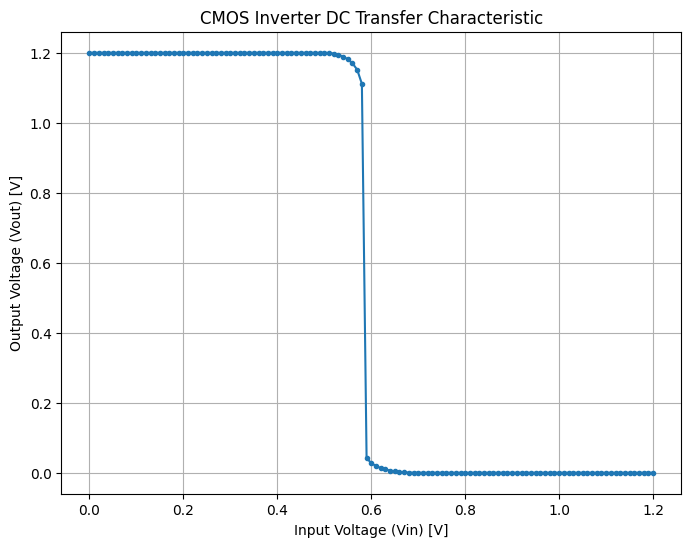


[Event 26] 
model_version=None content=Content(
  parts=[
    Part(
      function_response=FunctionResponse(
        id='adk-b8b3241d-bff9-4e97-a97a-27a70a54e353',
        name='simulate_cmos_inverter',
        response={
          'result': '{"v_hl10": 0.5893, "v_hl90": 0.5803, "v_lh10": 0.5893, "v_lh90": 0.5803}'
        }
      )
    ),
  ],
  role='user'
) grounding_metadata=None partial=None turn_complete=None finish_reason=None error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=None live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id=None invocation_id='e-640442b6-4d13-47a5-8fb9-87b79211cfc1' author='DCReviewer' actions=EventActions(skip_summarization=None, state_delta={}, artifact_delta={}, transfer_to_agent=None, escalate=None, requested_auth_configs={}, requested_tool_confirmations={}, compaction=None, end_of

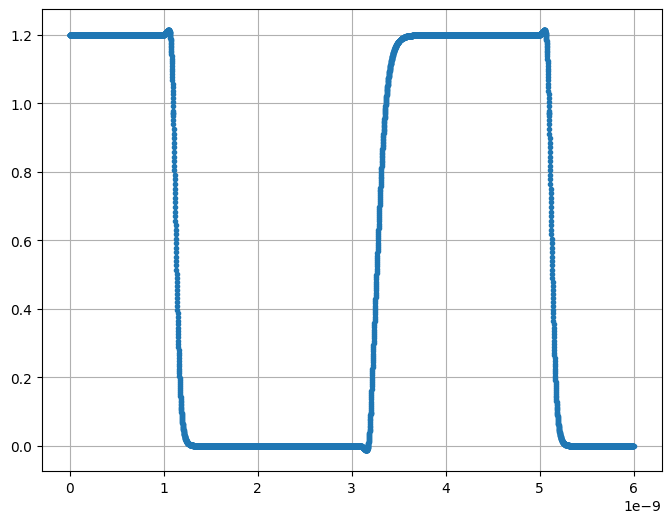


[Event 28] 
model_version=None content=Content(
  parts=[
    Part(
      function_response=FunctionResponse(
        id='adk-3f68e6db-c8cc-48f5-b238-6ed9324daa2b',
        name='transient_sim',
        response={
          'result': '{"t_hl": 92.111, "t_lh": 189.714}'
        }
      )
    ),
  ],
  role='user'
) grounding_metadata=None partial=None turn_complete=None finish_reason=None error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=None live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id=None invocation_id='e-640442b6-4d13-47a5-8fb9-87b79211cfc1' author='TransReviewer' actions=EventActions(skip_summarization=None, state_delta={}, artifact_delta={}, transfer_to_agent=None, escalate=None, requested_auth_configs={}, requested_tool_confirmations={}, compaction=None, end_of_agent=None, agent_state=None, rewind_before_

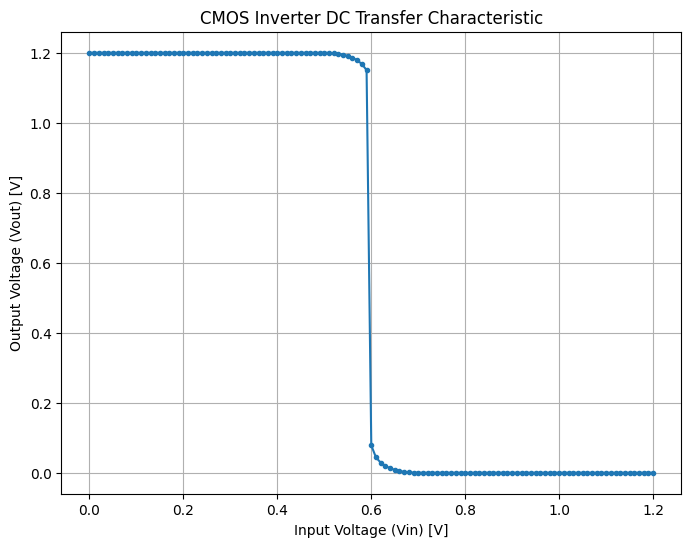


[Event 37] 
model_version=None content=Content(
  parts=[
    Part(
      function_response=FunctionResponse(
        id='adk-62d63362-c607-4aea-ac4a-aaec8222d624',
        name='simulate_cmos_inverter',
        response={
          'result': '{"v_hl10": 0.5996, "v_hl90": 0.5907, "v_lh10": 0.5996, "v_lh90": 0.5907}'
        }
      )
    ),
  ],
  role='user'
) grounding_metadata=None partial=None turn_complete=None finish_reason=None error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=None live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id=None invocation_id='e-640442b6-4d13-47a5-8fb9-87b79211cfc1' author='DCReviewer' actions=EventActions(skip_summarization=None, state_delta={}, artifact_delta={}, transfer_to_agent=None, escalate=None, requested_auth_configs={}, requested_tool_confirmations={}, compaction=None, end_of

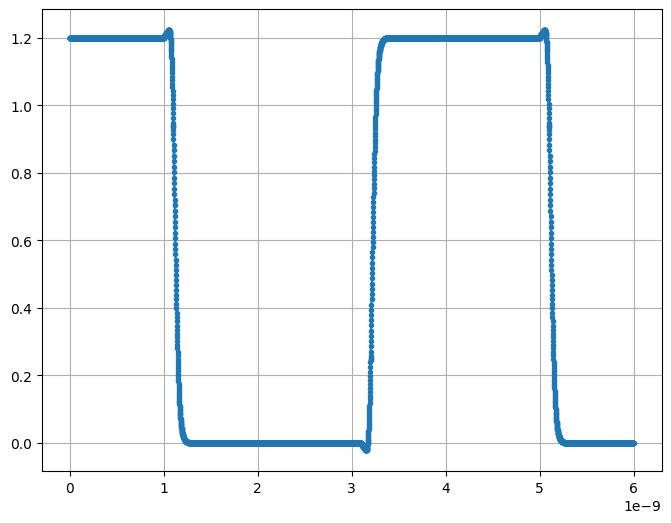


[Event 39] 
model_version=None content=Content(
  parts=[
    Part(
      function_response=FunctionResponse(
        id='adk-65ef2f4c-e451-456a-a2fb-c21e9eaaa44b',
        name='transient_sim',
        response={
          'result': '{"t_hl": 76.644, "t_lh": 80.233}'
        }
      )
    ),
  ],
  role='user'
) grounding_metadata=None partial=None turn_complete=None finish_reason=None error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=None live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id=None invocation_id='e-640442b6-4d13-47a5-8fb9-87b79211cfc1' author='TransReviewer' actions=EventActions(skip_summarization=None, state_delta={}, artifact_delta={}, transfer_to_agent=None, escalate=None, requested_auth_configs={}, requested_tool_confirmations={}, compaction=None, end_of_agent=None, agent_state=None, rewind_before_i

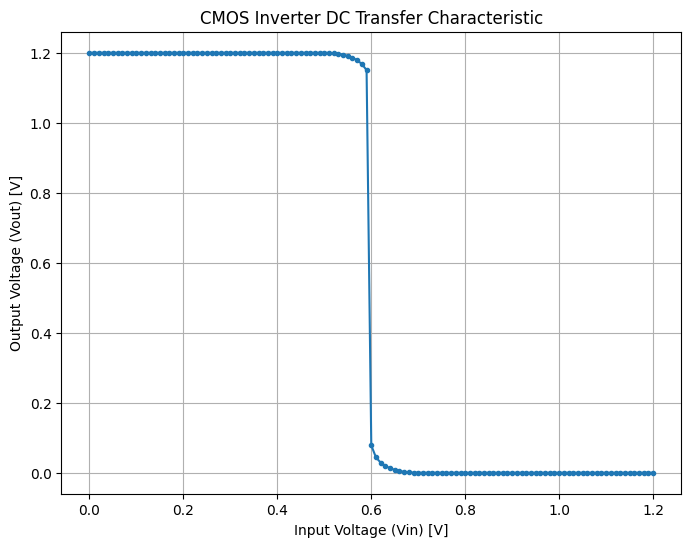


[Event 48] 
model_version=None content=Content(
  parts=[
    Part(
      function_response=FunctionResponse(
        id='adk-9c3e9462-0778-4754-ab01-b464c16dc9c7',
        name='simulate_cmos_inverter',
        response={
          'result': '{"v_hl10": 0.5996, "v_hl90": 0.5907, "v_lh10": 0.5996, "v_lh90": 0.5907}'
        }
      )
    ),
  ],
  role='user'
) grounding_metadata=None partial=None turn_complete=None finish_reason=None error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=None live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id=None invocation_id='e-640442b6-4d13-47a5-8fb9-87b79211cfc1' author='DCReviewer' actions=EventActions(skip_summarization=None, state_delta={}, artifact_delta={}, transfer_to_agent=None, escalate=None, requested_auth_configs={}, requested_tool_confirmations={}, compaction=None, end_of

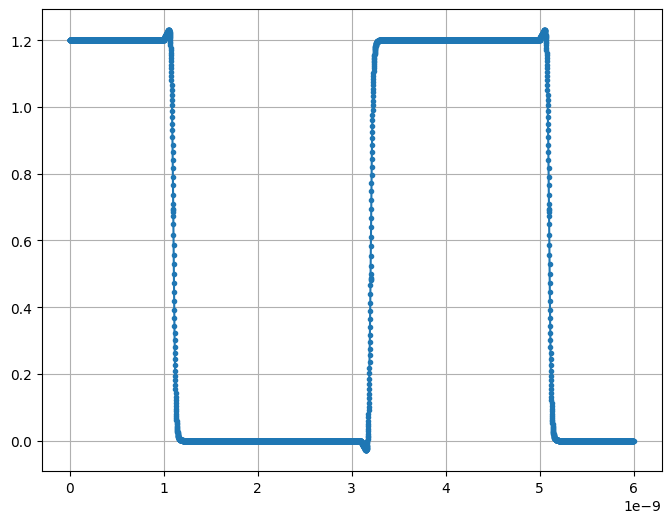


[Event 50] 
model_version=None content=Content(
  parts=[
    Part(
      function_response=FunctionResponse(
        id='adk-a3583cb7-ac90-49c7-96a9-db2daf25a487',
        name='transient_sim',
        response={
          'result': '{"t_hl": 45.213, "t_lh": 47.015}'
        }
      )
    ),
  ],
  role='user'
) grounding_metadata=None partial=None turn_complete=None finish_reason=None error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=None live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id=None invocation_id='e-640442b6-4d13-47a5-8fb9-87b79211cfc1' author='TransReviewer' actions=EventActions(skip_summarization=None, state_delta={}, artifact_delta={}, transfer_to_agent=None, escalate=None, requested_auth_configs={}, requested_tool_confirmations={}, compaction=None, end_of_agent=None, agent_state=None, rewind_before_i

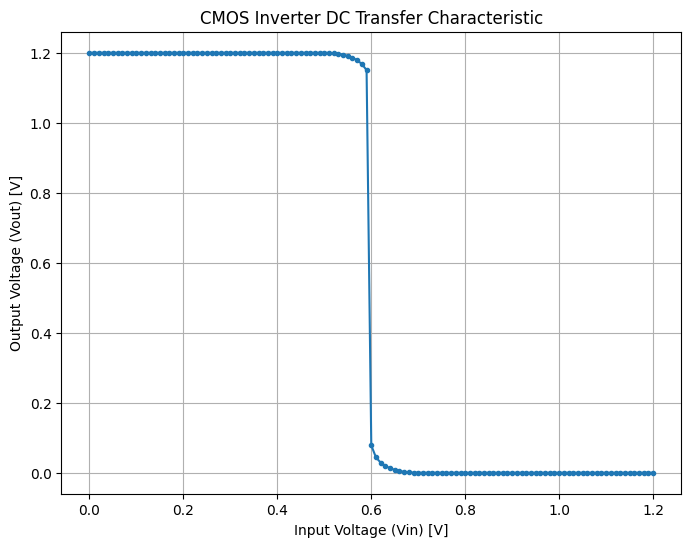

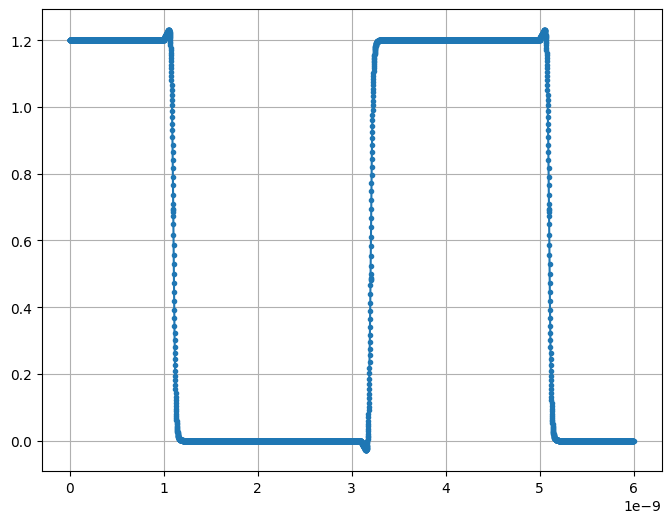


[Event 56] 
model_version=None content=Content(
  parts=[
    Part(
      function_response=FunctionResponse(
        id='adk-4f4c6b0a-bcd4-423c-aa84-1d9a14f019e2',
        name='simulate_cmos_inverter',
        response={
          'result': '{"v_hl10": 0.5996, "v_hl90": 0.5907, "v_lh10": 0.5996, "v_lh90": 0.5907}'
        }
      )
    ),
    Part(
      function_response=FunctionResponse(
        id='adk-179578e7-cdbb-4ca0-8552-1b7d0f8bad30',
        name='transient_sim',
        response={
          'result': '{"t_hl": 45.213, "t_lh": 47.015}'
        }
      )
    ),
  ],
  role='user'
) grounding_metadata=None partial=None turn_complete=None finish_reason=None error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=None live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id=None invocation_id='e-640442b6-4d13-47a5-8fb9-8

In [ ]:
specs = {
    "VTC_Spec":
     {"v_hl10": {"min": 0.58, "max": 0.62},
      "v_hl90": {"min": 0.58, "max": 0.62},
      "v_lh10": {"min": 0.58, "max": 0.62},
      "v_lh90": {"min": 0.58, "max": 0.62}},

    "Transient_Spec":
     {"t_hl_ps": {"min": 0, "max": 50},
    "t_lh_ps": {"min": 0, "max": 50}}
}
states = {
    "specs": specs,
    "current_params": {"Wp": None, "Wn": None},
    # --- PRE-POPULATE KEYS TO PREVENT CRASHES ---
    # These placeholders prevent KeyErrors if an agent fails to write its output
    "circuit_explanation": "(Pending Analysis)",
    "dc_sim_result": "(Pending simulation)",
    "trans_sim_result": "(Pending simulation)",
}

# 1. Initialize Service
APP_NAME = 'CMOS_sizer'
USER_ID = 'dev_user01'
SESSION_ID = 'pipeline_session_01'

session_service = InMemorySessionService()
await session_service.create_session(app_name=APP_NAME, user_id=USER_ID, session_id=SESSION_ID)
session = await session_service.get_session(app_name=APP_NAME, user_id=USER_ID, session_id=SESSION_ID)
# Update the state directly
if hasattr(session, 'state') and isinstance(session.state, dict):
    session.state.update(states)
elif hasattr(session, 'update_state'):
    await session.update_state(states)
else:
    # Fallback: Many in-memory implementations expose the storage dict directly
    session.state = states
print("✅ Session State Seeded with Placeholder Keys")

runner = Runner(agent=workflow, app_name=APP_NAME, session_service=session_service)

# 2. Prepare Input (Standard User Message)
# We still send this so the LLM knows what to do, even though State is set.
input_prompt = f"""
Here are the target specifications for a CMOS inverter with a 0.5fF parallel capacitor to ground at the output node.

SPECIFICATIONS:
{json.dumps(specs, indent=2)}

VTC_Spec parameters:
- v_hl10: Vin where Vout=0.12V (10% of VDD) during High-to-Low output transition. (H->L End of transition)
- v_hl90: Vin where Vout=1.08V (90% of VDD) during High-to-Low output transition. (H->L Start of transition)
- v_lh10: Vin where Vout=0.12V (10% of VDD) during Low-to-High output transition. (L->H Start of transition)
- v_lh90: Vin where Vout=1.08V (90% of VDD) during Low-to-High output transition. (L->H End of transition)
Transient_Spec parameters:
- t_hl: Fall time in picoseconds (High-to-Low) measured from 90% to 10% of VDD at the output.
- t_lh: Rise time in picoseconds (Low-to-High) measured from 10% to 90% of VDD at the output.

Here is the CMOS inverter netlist used for DC simulation:
* CMOS Inverter
.model model0_nmos nmos(level=1 vto=0.5 kp=35.2e-6 gamma=0.91 + cgso=210pF cgdo=210pF tox=50n)
.model model0_pmos pmos(level=1 vto=-0.5 kp=13.4e-6 gamma=0.64 + cgso=210pF cgdo=210pF tox=50n)

VDD vdd 0 1.2
VIN in 0 0
M1 out in vdd vdd model0_pmos w=wp l=40n
M2 out in 0 0 model0_nmos w=wn l=40n
C1 out 0 5f
* for forward sweep:
.dc VIN 0 1.2 0.01
* for backward sweep
.dc VIN 1.2 0 -0.01
.print dc v(out)
.end

Here is the CMOS inverter netlist used for transient simulation:
* CMOS Inverter Transient Analysis
.model model0_nmos nmos(level=1 vto=0.5 kp=35.2e-6 gamma=0.91 + cgso=210pF cgdo=210pF tox=50n)
.model model0_pmos pmos(level=1 vto=-0.5 kp=13.4e-6 gamma=0.64 + cgso=210pF cgdo=210pF tox=50n)

VDD vdd 0 1.2
VIN in 0 PULSE(0 1.2 1ns 100ps 100ps 2ns 4ns)
M1 out in vdd vdd model0_pmos w=wp l=40n
M2 out in 0 0 model0_nmos w=wn l=40n
C1 out 0 5f
.tran 0.001ns 6ns
.print tran v(in) v(out)
.end
"""

input_message = types.Content(
    role="user",
    parts=[types.Part(text=input_prompt)]
)

print("\n--- Execution Start ---")
try:
    execution_generator = runner.run(
        user_id=USER_ID,
        session_id=SESSION_ID,
        new_message=input_message
    )

    print("✅ Generator created. Stepping through events...")
    step_count = 0
    for event in execution_generator:
        step_count += 1
        print(f"\n[Event {step_count}] ")
        print(str(event))
        print("-" * 40)

    print("\nExecution Complete!")

except Exception as e:
    print(f"\n❌ EXECUTION ERROR: {e}")

In [ ]:
# Another way to implement HITL Feedback
# Response at the bottom: https://stackoverflow.com/questions/79612542/google-adk-sequentialagent-sub-agents-not-waiting-for-user-input
from google.adk.agents.callback_context import CallbackContext
from google.adk.agents import Agent, SequentialAgent, ParallelAgent, LoopAgent, LlmAgent, BaseAgent
from google.adk.models.google_llm import Gemini
from google.adk.models import LlmResponse, LlmRequest
from google.adk.runners import InMemoryRunner, Runner
from google.adk.tools import AgentTool, FunctionTool, google_search
from google.genai import types
from google.adk.tools.tool_context import ToolContext
from google.adk.sessions import DatabaseSessionService, InMemorySessionService
from google.adk.agents.invocation_context import InvocationContext
from google.adk.events import Event, EventActions

onboarding_agent = LlmAgent(
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    name="OnboardingAgent",
    instruction="""
    You are an onboarding concierge of an app that helps people with their groceries.
    Your goal is to get to know the user and save key information about them in your memory,
    using the tools below.
    0. Welcome them to Easy Peasy Onboarding!
    1. Ask them in what city they do their groceries and wait for their response
    2. Call the `save_city` tool to save their response
    11. Once you got number of meals, create a dictionary with all the values
    """,
    # before_model_callback=skip_onboarding_if_complete,
    tools=[save_city],
    output_key="user_dict",
)

recipe_pipeline = SequentialAgent(
    name="RecipePipeline",
    sub_agents=[ingredients_in_season_agent, recipe_agent],
)

class MyTurnBasedAgents(BaseAgent):
    onboarding_agent: LlmAgent
    recipe_pipeline: SequentialAgent

    def __init__(
        self,
        name: str,
        onboarding_agent: LlmAgent,
        recipe_pipeline: SequentialAgent,
    ):
        """Agent that gives spaces to agents who need to talk to users

        Args:
            name (str): Name of the custom agent
            agent_that_takes_turns (LlmAgent): name of the agent that needs space.
        """
        super().__init__(
            name=name,
            onboarding_agent=onboarding_agent,
            recipe_pipeline=recipe_pipeline,
        )

    async def _run_async_impl(
        self, ctx: InvocationContext
    ) -> AsyncGenerator[Event, None]:
        async for event in self.onboarding_agent.run_async(ctx):
            yield event

        if "user:number_of_meals" in ctx.session.state:
            async for event in self.recipe_pipeline.run_async(ctx):
                yield event